In [ ]:
%pip install torchvision

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.6/7.6 MB 78.5 MB/s  0:00:00
Note: you may need to restart the kernel to use updated packages.


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt


data = torchvision.datasets.CIFAR10(download=True, root="./")

In [4]:
labels = ["airplane", "automobile", "bird", "cat", "deer", "dog", "frog", "horse", "ship", "truck"]
labels_check = [0 for i in range(10)]
images = [[] for i in range(10)]

for (image, label) in data:
    if labels_check[label] == 0:
        labels_check[label] = 1
        images[label] = image

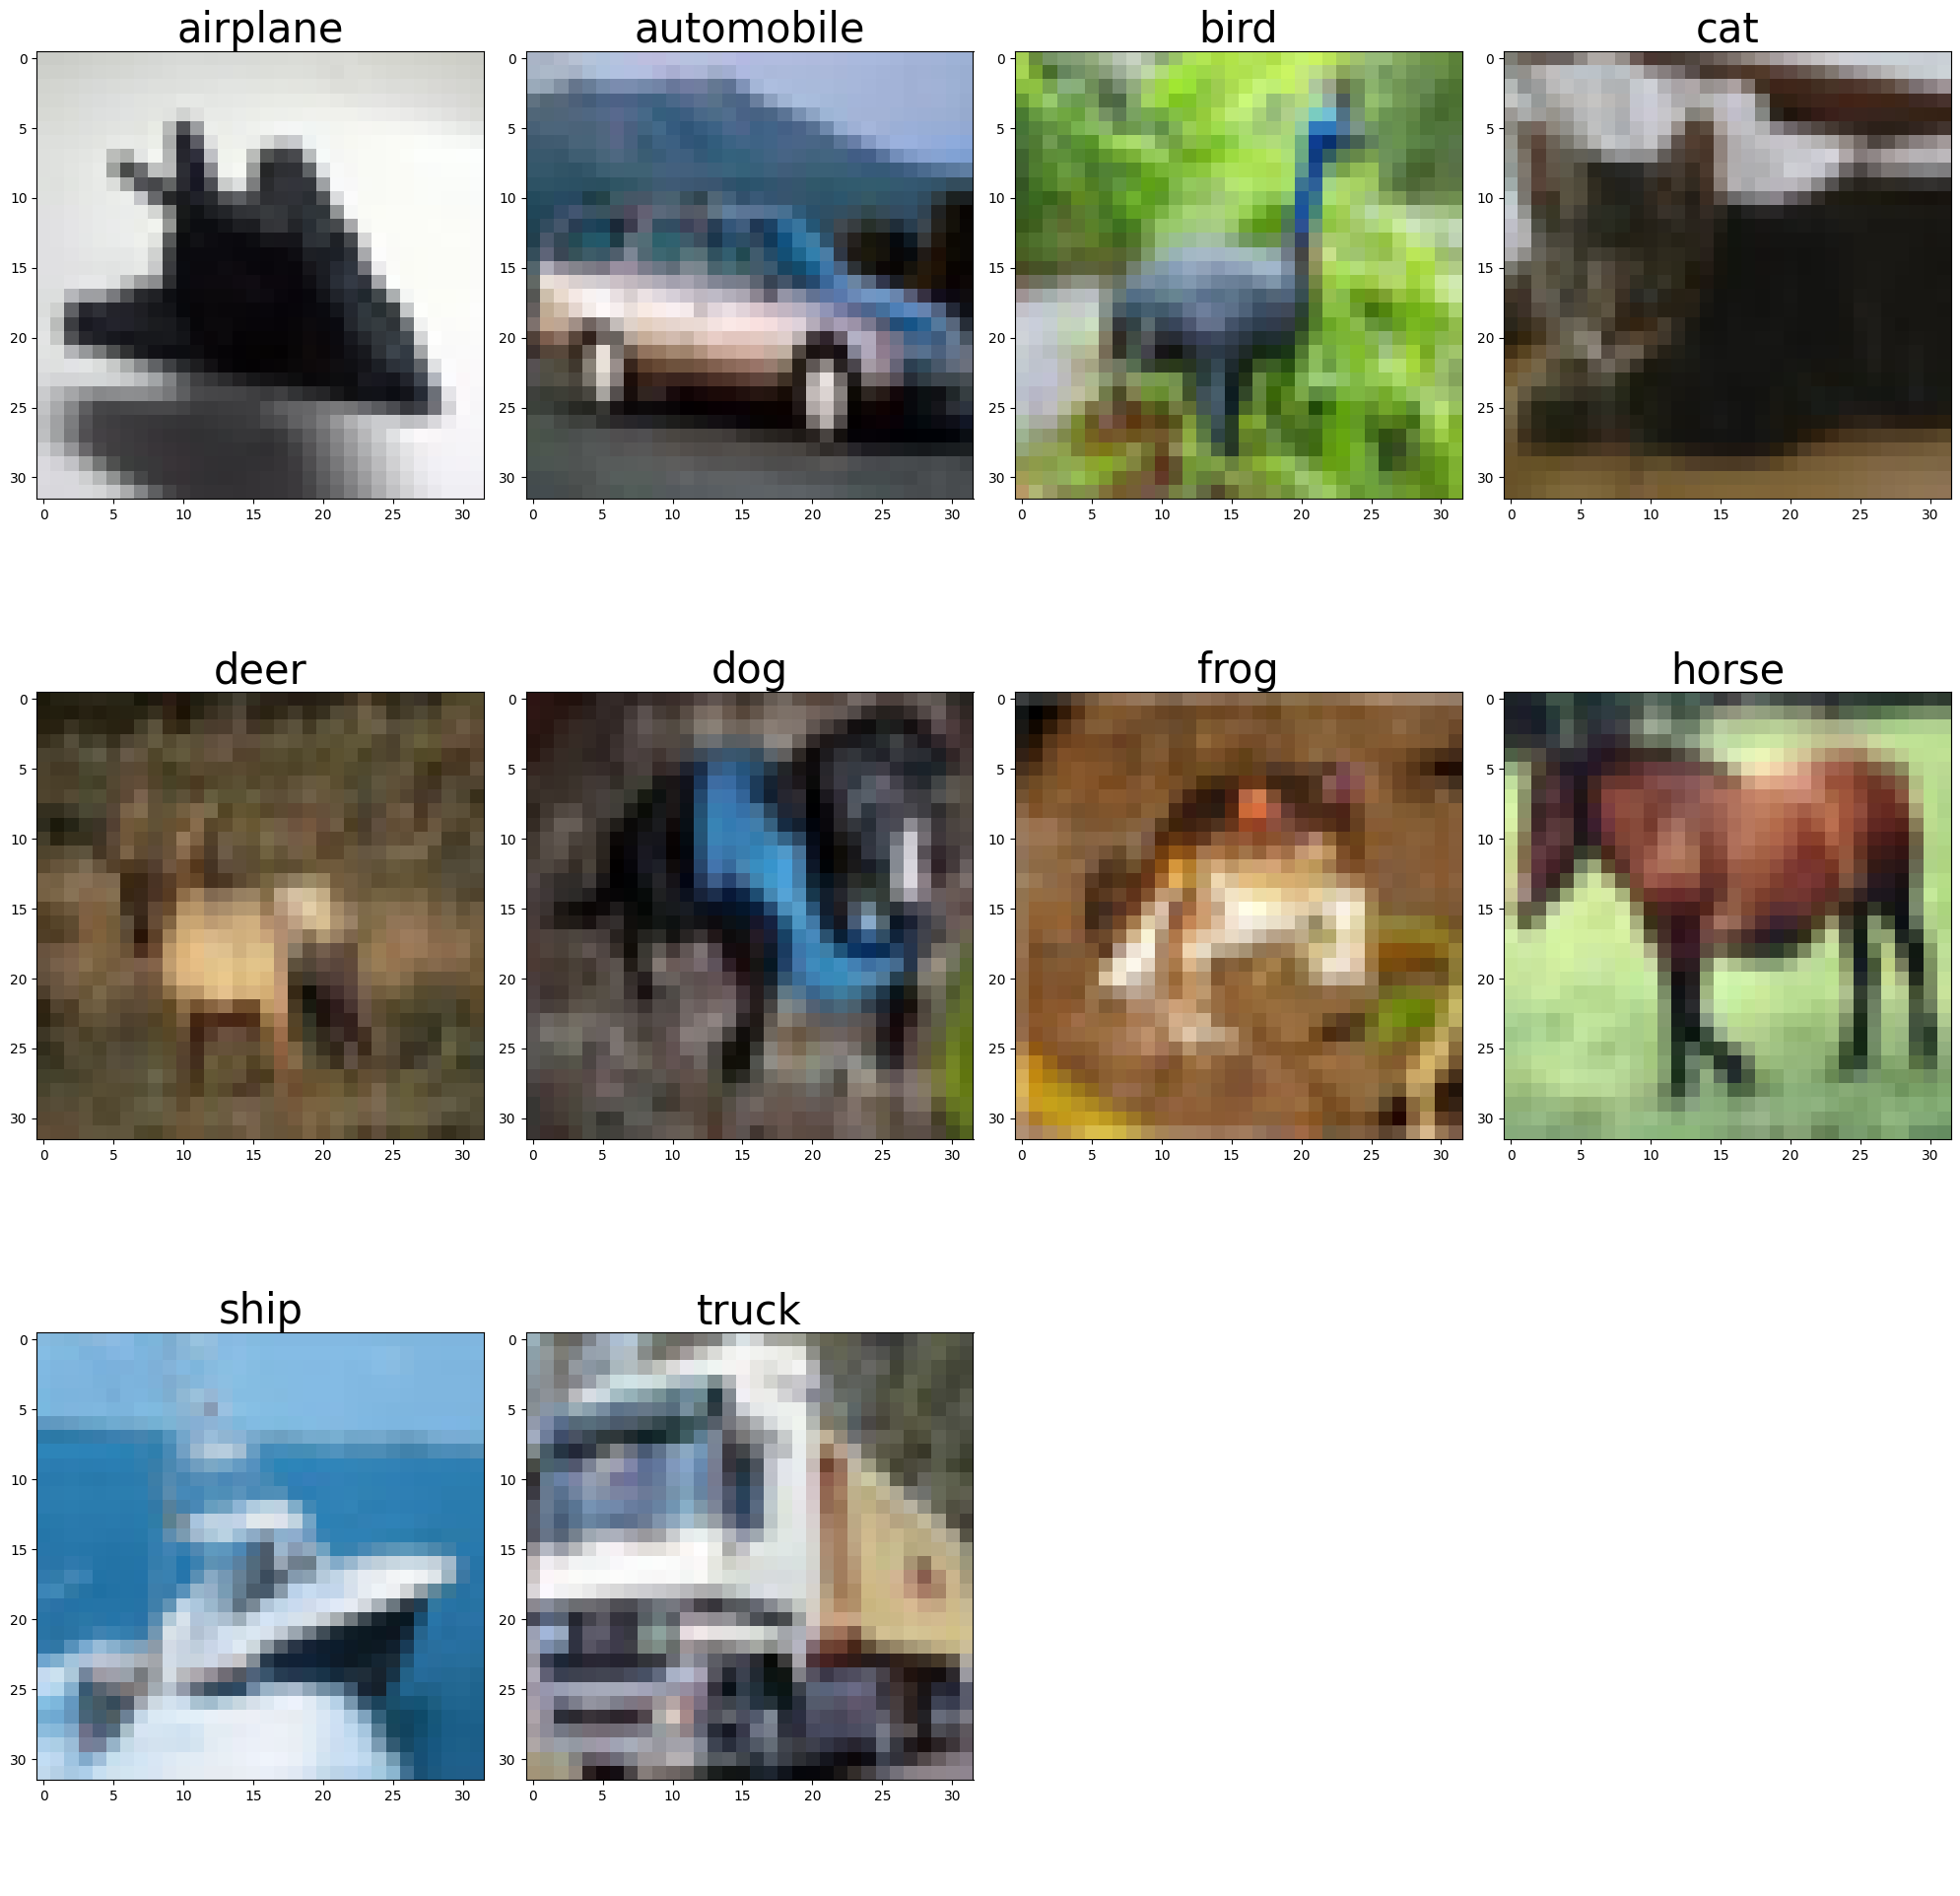

In [20]:
fig, axs = plt.subplots(3,4, figsize=(20,20))

for i in range(len(labels)):
    axs[i // 4, i%4].imshow(images[i])
    axs[i // 4, i%4].set_title(labels[i], fontsize=30)

for i in range(len(labels), 3*4):
    axs[i // 4, i%4].axis('off')

plt.tight_layout()
plt.show()

In [5]:
labels_count = [0 for i in range(10)]

for (image, label) in data:
    labels_count[label] +=1

<BarContainer object of 10 artists>

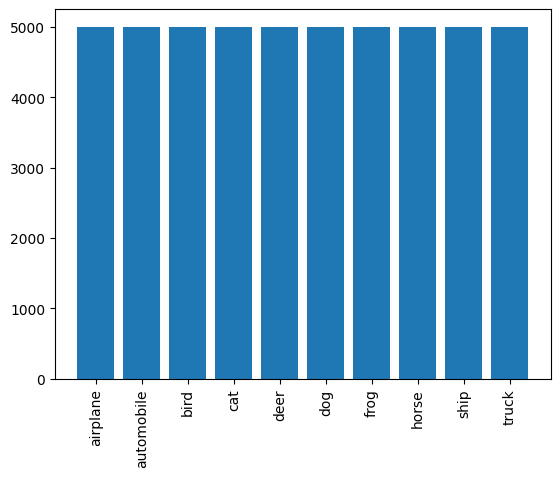

In [6]:
plt.xticks(rotation=90)
plt.bar(labels, labels_count)

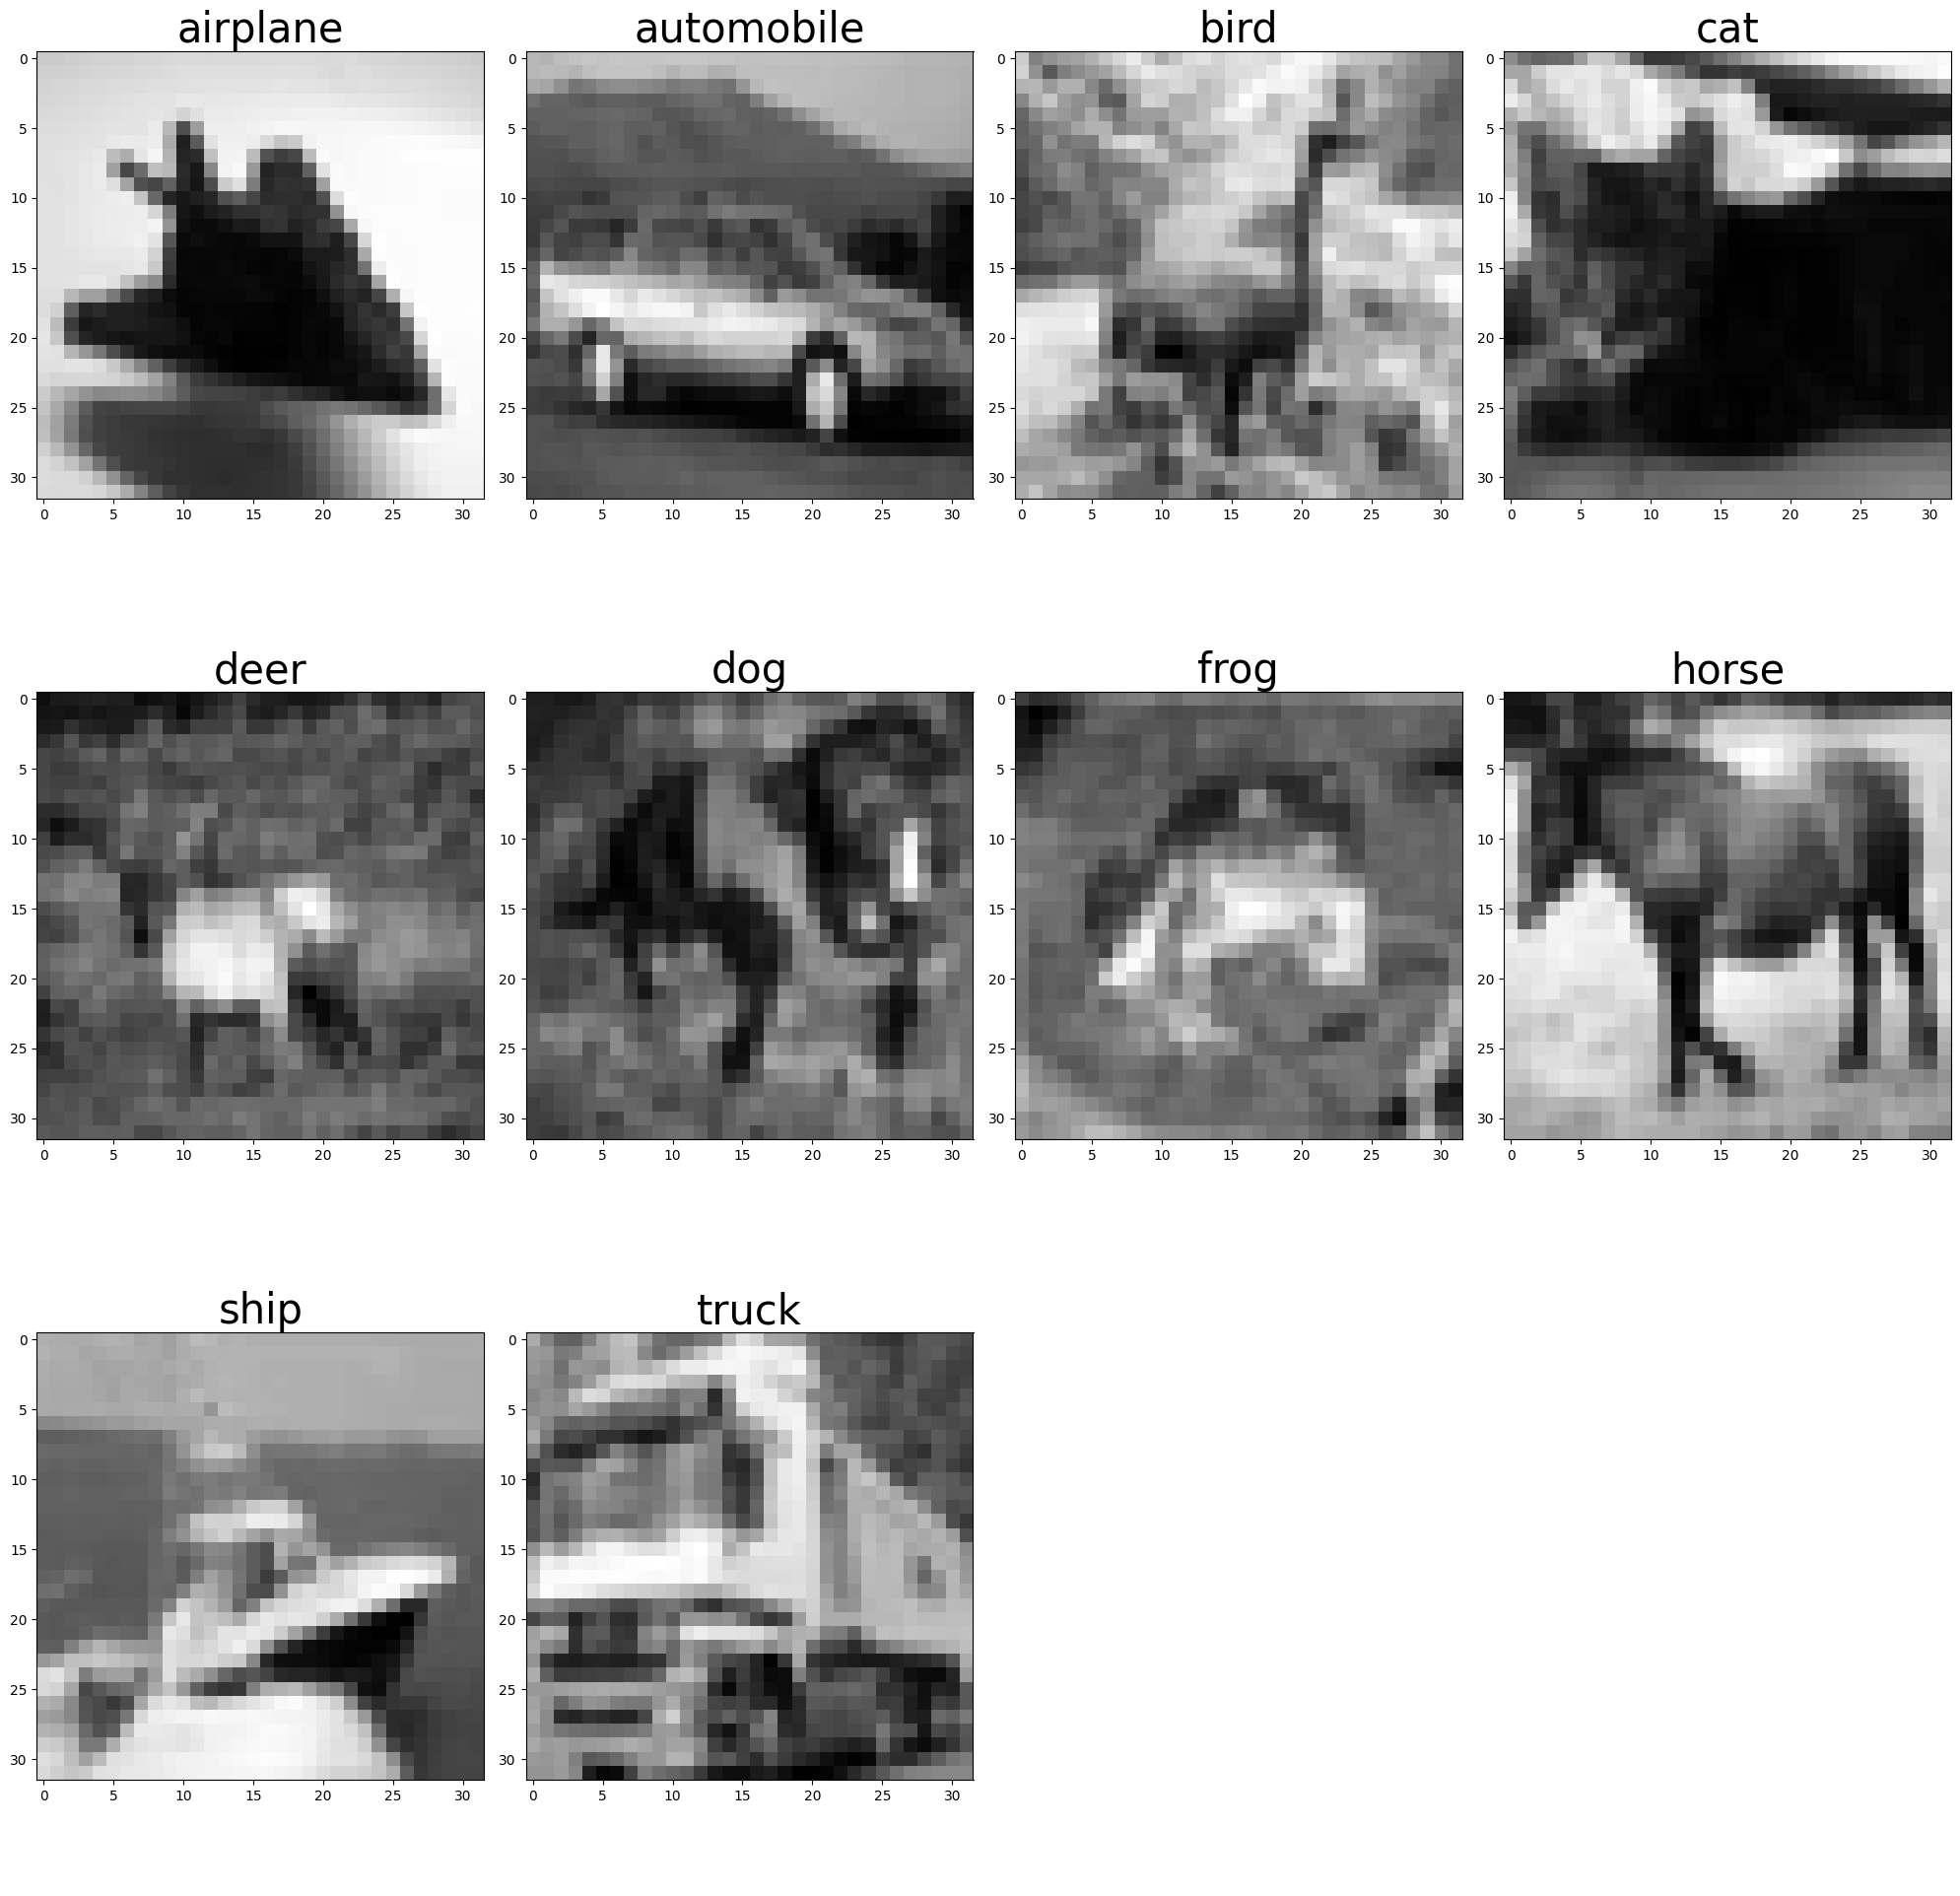

In [7]:
fig, axs = plt.subplots(3,4, figsize=(20,20))

for i in range(len(labels)):
    axs[i // 4, i%4].imshow(images[i].convert("L"),  cmap=plt.get_cmap('gray'))
    axs[i // 4, i%4].set_title(labels[i], fontsize=30)

for i in range(len(labels), 3*4):
    axs[i // 4, i%4].axis('off')

plt.tight_layout()
plt.show()

In [8]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

Device: cpu


## Préparation des données

Avant l'entraînement, les images de CIFAR-10 sont prétraitées afin d'améliorer les performances du modèle.

Pour le jeu d'entraînement, nous appliquons une augmentation de données (même si celle ci n'est pas demandée pour cette partie) composée d'un recadrage aléatoire  et d'un retournement horizontal. Ces transformations permettent de générer de nouvelles variantes des images et d'améliorer la capacité de généralisation du modèle.

Les images sont ensuite converties en tenseurs puis normalisées à l'aide de la moyenne et de l'écart-type du jeu de données CIFAR-10.

Pour le jeu de test, seules la conversion en tenseur et la normalisation sont appliquées afin d'évaluer les modèles sur des données non modifiées.

Enfin, les données sont chargées avec `DataLoader`, en mélangeant les exemples d'entraînement (`shuffle=True`) tout en conservant un ordre fixe pour le jeu de test.

In [25]:
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        (0.4914, 0.4822, 0.4465),
        (0.2470, 0.2435, 0.2616)
    ),
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        (0.4914, 0.4822, 0.4465),
        (0.2470, 0.2435, 0.2616)
    ),
])

train_set = torchvision.datasets.CIFAR10(
    root="./",
    train=True,
    download=True,
    transform=transform_train
)

test_set = torchvision.datasets.CIFAR10(
    root="./",
    train=False,
    download=True,
    transform=transform_test
)

train_loader = DataLoader(
    train_set,
    batch_size=128,
    shuffle=True,
    num_workers=2
)

test_loader = DataLoader(
    test_set,
    batch_size=256,
    shuffle=False,
    num_workers=2
)


## Fonctions d'entraînement et d'évaluation

Afin de comparer les différents modèles dans les mêmes conditions, nous avons défini trois fonctions : `train_one_epoch`, `evaluate` et `run`.

La fonction `train_one_epoch` réalise une époque complète d'entraînement. Pour chaque batch, elle effectue une propagation avant, calcule la perte (`CrossEntropyLoss`), réalise la rétropropagation puis met à jour les poids du réseau à l'aide de l'optimiseur. Elle retourne la perte moyenne et l'accuracy sur le jeu d'entraînement.

La fonction `evaluate` mesure les performances du modèle sur le jeu de test. Le modèle est placé en mode évaluation (`model.eval()`) et le calcul des gradients est désactivé (`@torch.no_grad()`), ce qui réduit le temps de calcul.

Enfin, la fonction `run` regroupe l'ensemble du processus d'entraînement. Elle initialise la fonction de coût, l'optimiseur et le scheduler, puis enchaîne les phases d'entraînement et d'évaluation pendant plusieurs époques. Les différentes métriques sont enregistrées dans un dictionnaire afin de faciliter la comparaison des modèles.

In [26]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    correct = 0
    total = 0
    total_loss = 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x.size(0)
        correct += (logits.argmax(1) == y).sum().item()
        total += y.size(0)

    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    correct = 0
    total = 0
    total_loss = 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)

        logits = model(x)
        loss = criterion(logits, y)

        total_loss += loss.item() * x.size(0)
        correct += (logits.argmax(1) == y).sum().item()
        total += y.size(0)

    return total_loss / total, correct / total


def run(model, epochs=20, lr=0.1, weight_decay=5e-4):

    model = model.to(device)

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.SGD(
        model.parameters(),
        lr=lr,
        momentum=0.9,
        weight_decay=weight_decay
    )

    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=epochs
    )

    history = {
        "train_loss": [],
        "train_acc": [],
        "test_loss": [],
        "test_acc": [],
    }

    print("=" * 50)
    print("Training:", model.__class__.__name__)
    print("=" * 50)

    for epoch in range(epochs):

        train_loss, train_acc = train_one_epoch(
            model,
            train_loader,
            optimizer,
            criterion
        )

        test_loss, test_acc = evaluate(
            model,
            test_loader,
            criterion
        )

        scheduler.step()

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["test_loss"].append(test_loss)
        history["test_acc"].append(test_acc)

        print(
            f"Epoch {epoch+1:02d}/{epochs} | "
            f"train acc: {train_acc:.3f} | "
            f"test acc: {test_acc:.3f} | "
            f"test loss: {test_loss:.3f}"
        )

    results = {
        "model": model,
        "history": history,
        "final_test_acc": history["test_acc"][-1],
        "final_test_loss": history["test_loss"][-1],
        "best_test_acc": max(history["test_acc"])
    }

    return results

results = {}

## CNN de référence

Nous commençons par reproduire le réseau convolutif étudié en TD, qui servira de modèle de référence pour toutes les expériences suivantes.

L'architecture est composée de trois blocs convolutionnels. Chaque bloc comprend une convolution suivie d'une fonction d'activation ReLU. Les deux premiers blocs se terminent par une opération de **MaxPooling** afin de réduire progressivement la taille des cartes de caractéristiques. Le dernier bloc utilise un **Adaptive Average Pooling**, qui produit un vecteur de caractéristiques de taille fixe indépendamment de la taille des cartes.

Le classifieur est constitué d'une couche entièrement connectée de 128 neurones, suivie d'une activation ReLU et d'un **Dropout** pour limiter le surapprentissage. Une dernière couche linéaire produit les scores associés aux 10 classes du jeu de données CIFAR-10.

Ce modèle constitue une base de comparaison pour évaluer l'apport des architectures plus profondes et plus complexes étudiées par la suite.

In [28]:
class CNN_TD(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        self.features = nn.Sequential(

            # 32x32 -> 16x16
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # 16x16 -> 8x8
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # 8x8 -> 1x1
            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x
    

model = CNN_TD()

results["CNN_TD"] = run(
    model,
    epochs=20,
    lr=0.1
)

Training: CNN_TD
Epoch 01/20 | train acc: 0.248 | test acc: 0.344 | test loss: 1.726
Epoch 02/20 | train acc: 0.385 | test acc: 0.446 | test loss: 1.461
Epoch 03/20 | train acc: 0.462 | test acc: 0.515 | test loss: 1.338
Epoch 04/20 | train acc: 0.523 | test acc: 0.569 | test loss: 1.216
Epoch 05/20 | train acc: 0.574 | test acc: 0.614 | test loss: 1.074
Epoch 06/20 | train acc: 0.608 | test acc: 0.651 | test loss: 0.975
Epoch 07/20 | train acc: 0.638 | test acc: 0.668 | test loss: 0.936
Epoch 08/20 | train acc: 0.660 | test acc: 0.656 | test loss: 0.954
Epoch 09/20 | train acc: 0.681 | test acc: 0.710 | test loss: 0.821
Epoch 10/20 | train acc: 0.699 | test acc: 0.708 | test loss: 0.833
Epoch 11/20 | train acc: 0.716 | test acc: 0.741 | test loss: 0.748
Epoch 12/20 | train acc: 0.732 | test acc: 0.730 | test loss: 0.777
Epoch 13/20 | train acc: 0.744 | test acc: 0.735 | test loss: 0.745
Epoch 14/20 | train acc: 0.757 | test acc: 0.754 | test loss: 0.698
Epoch 15/20 | train acc: 0.771 

### Noir et blanc

Nous cherchons à évaluer l'importance de l'information colorimétrique dans la classification des images. Pour cela, nous convertissons les images RGB en niveaux de gris et entraînons le même réseau dans les mêmes conditions.

En comparant les résultats obtenus sur les images en couleur et en noir et blanc, nous pouvons ainsi mesurer la contribution de l'information de couleur à la performance globale du modèle.

In [18]:
#Ici on convertit en noir et blanc chaque image
transform_gray = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset_gray = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform_gray
)

test_dataset_gray = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=transform_gray
)

train_loader_gray = torch.utils.data.DataLoader(
    train_dataset_gray,
    batch_size=128,
    shuffle=True
)

test_loader_gray = torch.utils.data.DataLoader(
    test_dataset_gray,
    batch_size=128,
    shuffle=False
)

# Pour ne pas réécrire la fonction run 
train_loader = train_loader_gray
test_loader = test_loader_gray

class CNN_TD_Gray(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        self.features = nn.Sequential(

            # 32x32 -> 16x16
            nn.Conv2d(1, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # 16x16 -> 8x8
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # 8x8 -> 1x1
            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x
    
model = CNN_TD_Gray()

results["CNN_TD_Gray"] = run(
    model,
    epochs=20,
    lr=0.1
)

Training: CNN_TD_Gray
Epoch 01/20 | train acc: 0.214 | test acc: 0.278 | test loss: 1.861
Epoch 02/20 | train acc: 0.342 | test acc: 0.384 | test loss: 1.621
Epoch 03/20 | train acc: 0.440 | test acc: 0.424 | test loss: 1.518
Epoch 04/20 | train acc: 0.502 | test acc: 0.514 | test loss: 1.356
Epoch 05/20 | train acc: 0.556 | test acc: 0.590 | test loss: 1.190
Epoch 06/20 | train acc: 0.583 | test acc: 0.613 | test loss: 1.070
Epoch 07/20 | train acc: 0.618 | test acc: 0.623 | test loss: 1.066
Epoch 08/20 | train acc: 0.645 | test acc: 0.649 | test loss: 1.030
Epoch 09/20 | train acc: 0.666 | test acc: 0.677 | test loss: 0.952
Epoch 10/20 | train acc: 0.690 | test acc: 0.679 | test loss: 0.938
Epoch 11/20 | train acc: 0.704 | test acc: 0.711 | test loss: 0.848
Epoch 12/20 | train acc: 0.721 | test acc: 0.667 | test loss: 0.952
Epoch 13/20 | train acc: 0.733 | test acc: 0.733 | test loss: 0.783
Epoch 14/20 | train acc: 0.750 | test acc: 0.732 | test loss: 0.790
Epoch 15/20 | train acc: 0

### Augmentation de nombre d'époques

Avant de modifier l'architecture du réseau, nous étudions l'impact du nombre d'époques sur les performances du modèle.

L'objectif est de vérifier si le modèle de référence a suffisamment convergé ou s'il peut encore améliorer ses performances en poursuivant son apprentissage.

Pour cette expérience, nous conservons exactement la même architecture et les mêmes hyperparamètres. Seul le nombre d'époques est augmenté. Cette approche permet d'isoler l'effet de la durée d'entraînement et de comparer ensuite ces résultats avec ceux obtenus grâce à des architectures plus complexes. 

In [27]:
train_loader = train_loader
test_loader = test_loader

model = CNN_TD()

results["CNN_TD_50"] = run(
    model,
    epochs=50,
    lr=0.1
)

Training: CNN_TD
Epoch 01/50 | train acc: 0.266 | test acc: 0.328 | test loss: 1.745
Epoch 02/50 | train acc: 0.401 | test acc: 0.463 | test loss: 1.448
Epoch 03/50 | train acc: 0.490 | test acc: 0.534 | test loss: 1.287
Epoch 04/50 | train acc: 0.542 | test acc: 0.601 | test loss: 1.106
Epoch 05/50 | train acc: 0.579 | test acc: 0.624 | test loss: 1.049
Epoch 06/50 | train acc: 0.607 | test acc: 0.589 | test loss: 1.198
Epoch 07/50 | train acc: 0.635 | test acc: 0.665 | test loss: 0.950
Epoch 08/50 | train acc: 0.656 | test acc: 0.665 | test loss: 0.937
Epoch 09/50 | train acc: 0.671 | test acc: 0.700 | test loss: 0.855
Epoch 10/50 | train acc: 0.689 | test acc: 0.703 | test loss: 0.857
Epoch 11/50 | train acc: 0.693 | test acc: 0.700 | test loss: 0.848
Epoch 12/50 | train acc: 0.701 | test acc: 0.708 | test loss: 0.835
Epoch 13/50 | train acc: 0.714 | test acc: 0.703 | test loss: 0.859
Epoch 14/50 | train acc: 0.721 | test acc: 0.720 | test loss: 0.797
Epoch 15/50 | train acc: 0.727 

### Conclusion sur le CNN de référence

Les trois expériences réalisées autour du `CNN_TD` permettent d'évaluer plusieurs facteurs simples avant de complexifier l'architecture.

Le modèle entraîné sur les images RGB fournit une première base de comparaison. L'expérience en noir et blanc montre que la couleur joue un rôle important dans la classification, car la suppression des canaux RGB réduit l'information disponible pour le modèle.

L'augmentation du nombre d'époques permet quant à elle de vérifier si le modèle peut encore progresser avec un entraînement plus long. Cependant, les gains restent limités par la capacité de représentation du réseau.

Ainsi, le `CNN_TD` constitue une bonne architecture de référence, mais ses performances restent limitées. Cela justifie ensuite l'exploration de modèles plus profonds et plus complexes.

## CNN profond

Nous faisons l'hypothèse que le modèle de référence n'est pas suffisamment profond pour capturer des caractéristiques visuelles complexes. Nous proposons donc une architecture composée de plusieurs blocs convolutionnels.

Le nombre de filtres augmente progressivement (`64 → 128 → 256 → 512`) afin d'apprendre des représentations de plus en plus riches. Chaque bloc est constitué de convolutions `3×3`, d'une **Batch Normalization**, d'une activation **ReLU**, d'un **MaxPooling** et d'un **Dropout** pour améliorer la stabilité de l'apprentissage et limiter le surapprentissage.

Le classifieur final est composé d'une couche **Flatten**, d'une couche dense de `512` neurones, suivie d'une activation **ReLU**, d'un **Dropout** et d'une dernière couche linéaire produisant les scores des `10` classes de CIFAR-10.

In [ ]:
class DeepCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        self.features = nn.Sequential(
            # Bloc 1 : 32x32 --> 16x16
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.2),

            # Bloc 2 : 16x16 --> 8x8
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.3),

            # Bloc 3 : 8x8 -> 4x4
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.4),

            # Bloc 4 : 4x4 -> 2x2
            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512 * 2 * 2, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.features(x))
    
model = DeepCNN()

results["DeepCNN"] = run(
    model,
    epochs=20,
    lr=0.05
)

Training: DeepCNN
Epoch 01/20 | train acc: 0.207 | test acc: 0.215 | test loss: 2.149
Epoch 02/20 | train acc: 0.306 | test acc: 0.436 | test loss: 1.507
Epoch 03/20 | train acc: 0.459 | test acc: 0.387 | test loss: 1.601
Epoch 04/20 | train acc: 0.578 | test acc: 0.603 | test loss: 1.098
Epoch 05/20 | train acc: 0.646 | test acc: 0.689 | test loss: 0.933
Epoch 06/20 | train acc: 0.692 | test acc: 0.683 | test loss: 0.953
Epoch 07/20 | train acc: 0.734 | test acc: 0.763 | test loss: 0.697
Epoch 08/20 | train acc: 0.758 | test acc: 0.780 | test loss: 0.674
Epoch 09/20 | train acc: 0.781 | test acc: 0.777 | test loss: 0.667
Epoch 10/20 | train acc: 0.797 | test acc: 0.815 | test loss: 0.535
Epoch 11/20 | train acc: 0.813 | test acc: 0.811 | test loss: 0.575
Epoch 12/20 | train acc: 0.825 | test acc: 0.842 | test loss: 0.469
Epoch 13/20 | train acc: 0.842 | test acc: 0.839 | test loss: 0.470
Epoch 14/20 | train acc: 0.852 | test acc: 0.865 | test loss: 0.401
Epoch 15/20 | train acc: 0.861

## VGG simplifiée

Nous testons également une architecture inspirée de **VGG**, dont le principe est d'empiler plusieurs convolutions `3×3` avant chaque opération de pooling afin d'augmenter progressivement la profondeur du réseau.

Le modèle est composé de trois blocs convolutionnels contenant chacun deux convolutions successives, suivies d'une **Batch Normalization**, d'une activation **ReLU** et d'un **MaxPooling**. Le nombre de filtres augmente progressivement (`64 → 128 → 256`) afin d'apprendre des caractéristiques de plus en plus complexes.

Le classifieur final est constitué d'une couche **Flatten**, d'une couche dense de `512` neurones, suivie d'une activation **ReLU**, d'un **Dropout** et d'une dernière couche linéaire produisant les scores des `10` classes de CIFAR-10.

In [37]:
class VGGSmall(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        self.features = nn.Sequential(
            # 32x32 -> 16x16
            nn.Conv2d(3, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # 16x16 -> 8x8
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
            ##nn.Flatten()

            # 8x8 -> 4x4
            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Conv2d(256, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 4 * 4, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.features(x))
    
model = VGGSmall()

results["VGGSmall"] = run(
    model,
    epochs=20,
    lr=0.05
)

Training: VGGSmall
Epoch 01/20 | train acc: 0.285 | test acc: 0.402 | test loss: 1.585
Epoch 02/20 | train acc: 0.475 | test acc: 0.573 | test loss: 1.133
Epoch 03/20 | train acc: 0.620 | test acc: 0.655 | test loss: 0.940
Epoch 04/20 | train acc: 0.697 | test acc: 0.718 | test loss: 0.821
Epoch 05/20 | train acc: 0.747 | test acc: 0.746 | test loss: 0.730
Epoch 06/20 | train acc: 0.783 | test acc: 0.780 | test loss: 0.660
Epoch 07/20 | train acc: 0.806 | test acc: 0.775 | test loss: 0.709
Epoch 08/20 | train acc: 0.824 | test acc: 0.798 | test loss: 0.591
Epoch 09/20 | train acc: 0.842 | test acc: 0.834 | test loss: 0.511
Epoch 10/20 | train acc: 0.857 | test acc: 0.830 | test loss: 0.530
Epoch 11/20 | train acc: 0.870 | test acc: 0.843 | test loss: 0.465
Epoch 12/20 | train acc: 0.885 | test acc: 0.857 | test loss: 0.428
Epoch 13/20 | train acc: 0.893 | test acc: 0.867 | test loss: 0.403
Epoch 14/20 | train acc: 0.908 | test acc: 0.875 | test loss: 0.393
Epoch 15/20 | train acc: 0.91

## MiniResNet

Nous proposons également une architecture inspirée de **ResNet**, reposant sur l'utilisation de **blocs résiduels** (*Residual Blocks*). L'objectif est de faciliter l'entraînement de réseaux plus profonds grâce aux **connexions résiduelles**, qui permettent une meilleure propagation du gradient.

L'architecture est composée d'une couche d'entrée (*stem*) suivie de trois *stages* de blocs résiduels. Le nombre de filtres augmente progressivement (`64 → 128 → 256`), tandis que la résolution spatiale diminue au fil des couches.

Chaque bloc résiduel est constitué de deux convolutions `3×3`, de couches **Batch Normalization** et d'activations **ReLU**. Une connexion résiduelle (*skip connection*) ajoute directement l'entrée du bloc à sa sortie, ce qui facilite l'apprentissage des représentations profondes.

Le réseau se termine par un **Global Average Pooling**, qui réduit les cartes de caractéristiques en un vecteur de taille fixe, suivi d'une couche linéaire produisant les scores des `10` classes de CIFAR-10.

In [14]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, stride=stride, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(),

            nn.Conv2d(out_channels, out_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
        )

        if stride != 1 or in_channels != out_channels:
            self.skip = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels),
            )
        else:
            self.skip = nn.Identity()

        self.relu = nn.ReLU()

    def forward(self, x):
        return self.relu(self.conv(x) + self.skip(x))


class MiniResNet(nn.Module):
    def __init__(self, blocks_per_stage=2):
        super().__init__()

        self.stem = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(),
        )

        self.stage1 = self._make_stage(64, 64, blocks_per_stage, stride=1)
        self.stage2 = self._make_stage(64, 128, blocks_per_stage, stride=2)
        self.stage3 = self._make_stage(128, 256, blocks_per_stage, stride=2)

        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Linear(256, 10)

    def _make_stage(self, in_c, out_c, n_blocks, stride):
        layers = [ResidualBlock(in_c, out_c, stride)]
        for _ in range(n_blocks - 1):
            layers.append(ResidualBlock(out_c, out_c, stride=1))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.stem(x)
        x = self.stage1(x)
        x = self.stage2(x)
        x = self.stage3(x)
        x = self.pool(x)
        x = x.flatten(1)
        return self.fc(x)
    
model = MiniResNet()

results["MiniResNet"] = run(
    model,
    epochs=20,
    lr=0.1
)

Training: MiniResNet
Epoch 01/20 | train acc: 0.369 | test acc: 0.470 | test loss: 1.523
Epoch 02/20 | train acc: 0.567 | test acc: 0.613 | test loss: 1.079
Epoch 03/20 | train acc: 0.662 | test acc: 0.609 | test loss: 1.167
Epoch 04/20 | train acc: 0.717 | test acc: 0.731 | test loss: 0.799
Epoch 05/20 | train acc: 0.770 | test acc: 0.731 | test loss: 0.759
Epoch 06/20 | train acc: 0.804 | test acc: 0.761 | test loss: 0.711
Epoch 07/20 | train acc: 0.825 | test acc: 0.766 | test loss: 0.716
Epoch 08/20 | train acc: 0.842 | test acc: 0.801 | test loss: 0.607
Epoch 09/20 | train acc: 0.855 | test acc: 0.824 | test loss: 0.544
Epoch 10/20 | train acc: 0.869 | test acc: 0.800 | test loss: 0.602
Epoch 11/20 | train acc: 0.882 | test acc: 0.817 | test loss: 0.590
Epoch 12/20 | train acc: 0.895 | test acc: 0.826 | test loss: 0.569
Epoch 13/20 | train acc: 0.908 | test acc: 0.863 | test loss: 0.414
Epoch 14/20 | train acc: 0.920 | test acc: 0.886 | test loss: 0.350
Epoch 15/20 | train acc: 0.

### Conclusion

Les trois architectures testées montrent qu'une augmentation de la profondeur et de la complexité du réseau permet d'améliorer les performances par rapport au modèle de référence.

Le **DeepCNN** offre un premier gain grâce à l'ajout de couches convolutionnelles et de mécanismes de régularisation. L'architecture **VGGSmall** améliore encore les résultats en empilant plusieurs convolutions successives. Enfin, **MiniResNet** obtient les meilleures performances grâce à l'utilisation de connexions résiduelles, qui facilitent l'apprentissage des représentations profondes.

Ces résultats confirment que le choix de l'architecture joue un rôle majeur dans les performances d'un réseau de neurones convolutif.

# CNN hybrides

Après avoir étudié plusieurs architectures de CNN conçues manuellement, nous nous intéressons à des modèles plus avancés reposant sur le **transfert d'apprentissage** (*Transfer Learning*).

L'objectif est de réutiliser des modèles pré-entraînés sur de grands jeux de données, comme **ImageNet**, afin de bénéficier de représentations visuelles déjà apprises. Ces modèles combinent des couches convolutionnelles performantes avec des mécanismes d'optimisation plus récents, ce qui leur permet d'obtenir de très bonnes performances tout en nécessitant moins de temps d'entraînement.

Dans cette partie, nous évaluons plusieurs architectures hybrides pré-entraînées, telles que **MobileNetV2**, **EfficientNetB0** et **MobileViT**, puis nous comparons leurs performances à celles des CNN développés précédemment.

### MobileNetV2Transfer

Pour cette expérience, nous utilisons **MobileNetV2**, une architecture de CNN légère conçue pour offrir un bon compromis entre performances et coût de calcul. Contrairement aux modèles développés précédemment, MobileNetV2 est pré-entraîné sur le jeu de données **ImageNet**, ce qui permet de réutiliser des caractéristiques visuelles déjà apprises.

Le classifieur d'origine est remplacé par une nouvelle couche linéaire adaptée aux `10` classes de CIFAR-10. Les couches d'extraction de caractéristiques sont conservées, tandis que seuls les derniers blocs du réseau et le nouveau classifieur sont réentraînés sur notre jeu de données.

Cette approche de **transfert d'apprentissage** permet d'obtenir rapidement de bonnes performances sans entraîner l'ensemble du réseau depuis une initialisation aléatoire.
Modèle de Google : https://huggingface.co/docs/transformers/model_doc/mobilenet_v2 

In [ ]:
from torchvision.models import mobilenet_v2, MobileNet_V2_Weights

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device utilisé :", device)

if device.type == "cuda":
    torch.backends.cudnn.benchmark = True


# =========================================================
# Transformations --> obligé de la faire car pas la même entrée 
# =========================================================

transform_mobilenet_train = transforms.Compose([
    transforms.Resize((224, 224)),              # Raison pour laquelle il est aussi lent...              
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225)
    )
])

transform_mobilenet_test = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225)
    )
])


# =========================================================
# Datasets + DataLoaders
# =========================================================

train_dataset_mobilenet = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform_mobilenet_train
)

test_dataset_mobilenet = torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform_mobilenet_test
)

train_loader_mobilenet = torch.utils.data.DataLoader(
    train_dataset_mobilenet,
    batch_size=128,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

test_loader_mobilenet = torch.utils.data.DataLoader(
    test_dataset_mobilenet,
    batch_size=128,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)


# =========================================================
# Modèle MobileNetV2 Transfer Learning
# =========================================================

class MobileNetV2Transfer(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        self.model = mobilenet_v2(                  # On prend les paramètres pré-entrainés 
            weights=MobileNet_V2_Weights.DEFAULT
        )

        self.model.classifier[1] = nn.Linear(       
            self.model.last_channel,
            num_classes
        )

        #Geler toutes les couches
        for param in self.model.features.parameters():      #Pour toutes les couches          
            param.requires_grad = False                     #Ne pas calculer le gradient 

        for param in self.model.features[-3:].parameters(): #Pour les 3 dernières 
            param.requires_grad = True                      #calculer

        for param in self.model.classifier.parameters():    #Classifieur 
            param.requires_grad = True

    def forward(self, x):
        return self.model(x)


# =========================================================
# Entraînement
# =========================================================

def run_transfer(model, train_loader, test_loader, epochs=20, lr=0.001):
    model = model.to(device)

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(                                                 #Sur le modèle de base ils utilisent Adam et non pas SGD, c'est peut être une des raisons pq il ets mauvais 
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr
    )

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=0.5,
        patience=3
    )

    history = {
        "train_loss": [],
        "train_acc": [],
        "test_loss": [],
        "test_acc": [],
    }

    for epoch in range(epochs):
        model.train()

        running_loss = 0.0
        running_correct = 0
        running_total = 0

        for images, labels in train_loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)

            preds = outputs.argmax(dim=1)
            running_correct += (preds == labels).sum().item()
            running_total += labels.size(0)

        train_loss = running_loss / running_total
        train_acc = running_correct / running_total

        model.eval()

        test_running_loss = 0.0
        test_running_correct = 0
        test_running_total = 0

        with torch.no_grad():                                           #On ne fait pas bakwards ==> pas de rétro propagation 
            for images, labels in test_loader:
                images = images.to(device, non_blocking=True)
                labels = labels.to(device, non_blocking=True)

                outputs = model(images)
                loss = criterion(outputs, labels)

                test_running_loss += loss.item() * images.size(0)

                preds = outputs.argmax(dim=1)
                test_running_correct += (preds == labels).sum().item()
                test_running_total += labels.size(0)

        test_loss = test_running_loss / test_running_total
        test_acc = test_running_correct / test_running_total

        scheduler.step(test_acc)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["test_loss"].append(test_loss)
        history["test_acc"].append(test_acc)

        print(
            f"Epoch {epoch + 1:02d}/{epochs} | "
            f"train loss: {train_loss:.3f} | "
            f"train acc: {train_acc:.3f} | "
            f"test loss: {test_loss:.3f} | "
            f"test acc: {test_acc:.3f} | "
            f"lr: {optimizer.param_groups[0]['lr']:.6f}"
        )

    return {
        "model": model,
        "history": history,
        "final_test_acc": history["test_acc"][-1],
        "final_test_loss": history["test_loss"][-1],
        "best_test_acc": max(history["test_acc"])
    }


# =========================================================
# Lancement
# =========================================================

results = {}

model = MobileNetV2Transfer()

results["MobileNetV2"] = run_transfer(
    model,
    train_loader_mobilenet,
    test_loader_mobilenet,
    epochs=10,
    lr=0.001
)

Device utilisé : cpu


c:\Users\dezhi\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\data\dataloader.py:1095: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 01/10 | train loss: 0.551 | train acc: 0.813 | test loss: 0.420 | test acc: 0.857 | lr: 0.001000
Epoch 02/10 | train loss: 0.331 | train acc: 0.884 | test loss: 0.386 | test acc: 0.869 | lr: 0.001000
Epoch 03/10 | train loss: 0.251 | train acc: 0.912 | test loss: 0.368 | test acc: 0.877 | lr: 0.001000
Epoch 04/10 | train loss: 0.194 | train acc: 0.933 | test loss: 0.392 | test acc: 0.876 | lr: 0.001000
Epoch 05/10 | train loss: 0.158 | train acc: 0.945 | test loss: 0.376 | test acc: 0.883 | lr: 0.001000
Epoch 06/10 | train loss: 0.131 | train acc: 0.954 | test loss: 0.385 | test acc: 0.885 | lr: 0.001000
Epoch 07/10 | train loss: 0.106 | train acc: 0.963 | test loss: 0.443 | test acc: 0.876 | lr: 0.001000
Epoch 08/10 | train loss: 0.094 | train acc: 0.968 | test loss: 0.425 | test acc: 0.886 | lr: 0.001000
Epoch 09/10 | train loss: 0.083 | train acc: 0.971 | test loss: 0.453 | test acc: 0.887 | lr: 0.001000
Epoch 10/10 | train loss: 0.072 | train acc: 0.974 | test loss: 0.469 | t

### MobileNetV2 optimisé

Afin d'améliorer les performances de MobileNetV2 sur CIFAR-10, nous utilisons une stratégie de **transfert d'apprentissage**.

Le modèle est initialisé avec des poids pré-entraînés sur **ImageNet**. La majorité des couches d'extraction de caractéristiques est gelée afin de conserver les connaissances déjà acquises. Seuls les trois derniers blocs convolutionnels ainsi que le classifieur final sont réentraînés pour s'adapter au nouveau jeu de données.

Le classifieur d'origine est remplacé par une couche linéaire produisant les scores des `10` classes de CIFAR-10.

L'entraînement est réalisé avec l'optimiseur **Adam** et un faible taux d'apprentissage (`0.001`) afin d'ajuster progressivement les poids. Un scheduler `ReduceLROnPlateau` est également utilisé pour diminuer automatiquement le taux d'apprentissage lorsque les performances cessent de progresser.

Enfin, les images sont redimensionnées en `224×224` et normalisées selon les statistiques d'ImageNet afin d'être compatibles avec le modèle pré-entraîné.

In [ ]:
from torchvision.models import mobilenet_v2, MobileNet_V2_Weights


# =========================================================
# Hyperparamètres
# =========================================================

IMG_SIZE = 160          # Plus rapide que 224
BATCH_SIZE =  128
EPOCHS = 15
LR = 5e-4
PATIENCE = 4


# =========================================================
# Transformations
# =========================================================

weights = MobileNet_V2_Weights.DEFAULT
mean = weights.transforms().mean
std = weights.transforms().std

transform_train = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),            
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15,
        saturation=0.15
    ),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std),
    transforms.RandomErasing(p=0.25)
])

transform_test = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])


# =========================================================
# Datasets
# =========================================================

train_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform_train
)

test_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform_test
)


# =========================================================
# DataLoaders
# =========================================================

num_workers = 4 if use_cuda else 2             #l'esoir de les faire en parallèle 

loader_kwargs = {
    "batch_size": BATCH_SIZE,
    "num_workers": num_workers,
    "pin_memory": use_cuda,
}

if num_workers > 0:
    loader_kwargs["persistent_workers"] = True
    loader_kwargs["prefetch_factor"] = 2

train_loader = DataLoader(
    train_dataset,
    shuffle=True,
    **loader_kwargs
)

test_loader = DataLoader(
    test_dataset,
    shuffle=False,
    **loader_kwargs
)


# =========================================================
# Modèle MobileNetV2
# =========================================================

class MobileNetV2Transfer(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        self.model = mobilenet_v2(weights=MobileNet_V2_Weights.DEFAULT)

        in_features = self.model.classifier[1].in_features

        self.model.classifier = nn.Sequential(
            nn.Dropout(p=0.35),
            nn.Linear(in_features, num_classes)
        )

        # Freeze complet
        for param in self.model.features.parameters():
            param.requires_grad = False

        # On fine-tune seulement les derniers blocs
        for param in self.model.features[-2:].parameters():
            param.requires_grad = True

        for param in self.model.classifier.parameters():
            param.requires_grad = True

    def forward(self, x):
        return self.model(x)


# =========================================================
# Train / Eval
# =========================================================

def train_one_epoch(model, loader, criterion, optimizer, scaler):
    model.train()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        if use_cuda:                                                 #j'ai toujours l'espoir d'avoir un bon pc... 
            images = images.to(memory_format=torch.channels_last)

        optimizer.zero_grad(set_to_none=True)

        with torch.autocast(device_type=device.type, enabled=use_cuda):
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        batch_size = labels.size(0)

        total_loss += loss.item() * batch_size
        total_correct += outputs.argmax(1).eq(labels).sum().item()
        total_samples += batch_size

    return total_loss / total_samples, total_correct / total_samples


@torch.inference_mode()
def evaluate(model, loader, criterion):
    model.eval()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        if use_cuda:
            images = images.to(memory_format=torch.channels_last)

        with torch.autocast(device_type=device.type, enabled=use_cuda):
            outputs = model(images)
            loss = criterion(outputs, labels)

        batch_size = labels.size(0)

        total_loss += loss.item() * batch_size
        total_correct += outputs.argmax(1).eq(labels).sum().item()
        total_samples += batch_size

    return total_loss / total_samples, total_correct / total_samples


# =========================================================
# Entraînement complet
# =========================================================

def run_transfer(model, train_loader, test_loader, epochs=EPOCHS, lr=LR):
    model = model.to(device)

    if use_cuda:
        model = model.to(memory_format=torch.channels_last)

    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

    optimizer = optim.AdamW(                #version d'Adam qui fait varier le taux d'apprentissage 
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr,
        weight_decay=1e-3
    )

    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=epochs
    )

    scaler = torch.amp.GradScaler("cuda", enabled=use_cuda)

    history = {
        "train_loss": [],
        "train_acc": [],
        "test_loss": [],
        "test_acc": [],
    }

    best_acc = 0.0
    best_model_state = None
    patience_counter = 0

    for epoch in range(epochs):
        train_loss, train_acc = train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer,
            scaler
        )

        test_loss, test_acc = evaluate(
            model,
            test_loader,
            criterion
        )

        scheduler.step()

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["test_loss"].append(test_loss)
        history["test_acc"].append(test_acc)

        #EarlyStop 
        if test_acc > best_acc:
            best_acc = test_acc
            best_model_state = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1

        print(
            f"Epoch {epoch + 1:02d}/{epochs} | "
            f"train loss: {train_loss:.3f} | "
            f"train acc: {train_acc:.3f} | "
            f"test loss: {test_loss:.3f} | "
            f"test acc: {test_acc:.3f} | "
            f"best acc: {best_acc:.3f} | "
            f"lr: {optimizer.param_groups[0]['lr']:.6f}"
        )
        
        #EarlyStop si 4 époques sans améliorations
        if patience_counter >= PATIENCE:
            print("Early stopping déclenché.")
            break

    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    return {
        "model": model,
        "history": history,
        "final_test_acc": history["test_acc"][-1],
        "final_test_loss": history["test_loss"][-1],
        "best_test_acc": best_acc
    }


# =========================================================
# Lancement
# =========================================================

results = {}

model = MobileNetV2Transfer()

results["MobileNetV2"] = run_transfer(
    model,
    train_loader,
    test_loader,
    epochs=EPOCHS,
    lr=LR
)

print("Meilleure accuracy test :", results["MobileNetV2"]["best_test_acc"])

Device utilisé : cpu
Epoch 01/15 | train loss: 1.087 | train acc: 0.761 | test loss: 0.891 | test acc: 0.851 | best acc: 0.851 | lr: 0.000495
Epoch 02/15 | train loss: 0.934 | train acc: 0.826 | test loss: 0.851 | test acc: 0.862 | best acc: 0.862 | lr: 0.000478
Epoch 03/15 | train loss: 0.895 | train acc: 0.840 | test loss: 0.824 | test acc: 0.874 | best acc: 0.874 | lr: 0.000452
Epoch 04/15 | train loss: 0.868 | train acc: 0.852 | test loss: 0.804 | test acc: 0.884 | best acc: 0.884 | lr: 0.000417
Epoch 05/15 | train loss: 0.848 | train acc: 0.864 | test loss: 0.807 | test acc: 0.882 | best acc: 0.884 | lr: 0.000375
Epoch 06/15 | train loss: 0.839 | train acc: 0.866 | test loss: 0.788 | test acc: 0.890 | best acc: 0.890 | lr: 0.000327
Epoch 07/15 | train loss: 0.825 | train acc: 0.872 | test loss: 0.785 | test acc: 0.890 | best acc: 0.890 | lr: 0.000276
Epoch 08/15 | train loss: 0.815 | train acc: 0.877 | test loss: 0.783 | test acc: 0.892 | best acc: 0.892 | lr: 0.000224
Epoch 09/15

### EfficientNet-B0

Nous évaluons également **EfficientNet-B0**, une architecture récente conçue pour offrir un excellent compromis entre précision et coût de calcul. Contrairement aux CNN classiques, EfficientNet applique une mise à l'échelle équilibrée de la profondeur, de la largeur et de la résolution des images, ce qui permet d'obtenir de bonnes performances avec un nombre limité de paramètres.

Comme pour MobileNetV2, nous utilisons un modèle **pré-entraîné sur ImageNet** dans le cadre d'un transfert d'apprentissage. Le classifieur d'origine est remplacé par une couche linéaire adaptée aux `10` classes de CIFAR-10. Les premières couches du réseau sont gelées, tandis que les dernières couches et le classifieur sont réentraînés afin d'adapter le modèle au nouveau jeu de données.

L'entraînement est réalisé avec l'optimiseur **Adam**, un faible taux d'apprentissage et des images redimensionnées puis normalisées selon les statistiques d'ImageNet.

 https://arxiv.org/abs/1905.11946 

In [ ]:
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights


# =========================================================
# Device
# =========================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device utilisé :", device)

use_cuda = device.type == "cuda"

if use_cuda:
    torch.backends.cudnn.benchmark = True
    torch.set_float32_matmul_precision("high")


# =========================================================
# Hyperparamètres
# =========================================================

IMG_SIZE = 160
BATCH_SIZE = 256 if use_cuda else 128
EPOCHS = 15
LR = 5e-4
PATIENCE = 4


# =========================================================
# Transformations
# =========================================================

weights = EfficientNet_B0_Weights.DEFAULT
mean = weights.transforms().mean
std = weights.transforms().std

#Data augmentation preconisé par la recherche
transform_train = transforms.Compose([              
    transforms.Resize((IMG_SIZE, IMG_SIZE)),            #160*160 
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10), 
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.15),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std),
    transforms.RandomErasing(p=0.25)
])

transform_test = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])


# =========================================================
# Datasets
# =========================================================

train_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform_train
)

test_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform_test
)


# =========================================================
# DataLoaders
# =========================================================

num_workers = 4 if use_cuda else 2

loader_kwargs = {
    "batch_size": BATCH_SIZE,
    "num_workers": num_workers,
    "pin_memory": use_cuda,
}

if num_workers > 0:
    loader_kwargs["persistent_workers"] = True
    loader_kwargs["prefetch_factor"] = 2

train_loader = DataLoader(
    train_dataset,
    shuffle=True,
    **loader_kwargs
)

test_loader = DataLoader(
    test_dataset,
    shuffle=False,
    **loader_kwargs
)


# =========================================================
# Modèle EfficientNet-B0 Transfer Learning
# =========================================================

class EfficientNetB0Transfer(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        self.model = efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)

        in_features = self.model.classifier[1].in_features

        self.model.classifier = nn.Sequential(
            nn.Dropout(p=0.35),
            nn.Linear(in_features, num_classes)
        )

        for param in self.model.features.parameters():
            param.requires_grad = False

        for param in self.model.features[-2:].parameters():
            param.requires_grad = True

        for param in self.model.classifier.parameters():
            param.requires_grad = True

    def forward(self, x):
        return self.model(x)


# =========================================================
# Train / Eval
# =========================================================

def train_one_epoch(model, loader, criterion, optimizer, scaler):
    model.train()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        if use_cuda:
            images = images.to(memory_format=torch.channels_last)

        optimizer.zero_grad(set_to_none=True)

        with torch.autocast(device_type=device.type, enabled=use_cuda):
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        batch_size = labels.size(0)
        total_loss += loss.item() * batch_size
        total_correct += outputs.argmax(1).eq(labels).sum().item()
        total_samples += batch_size

    return total_loss / total_samples, total_correct / total_samples


@torch.inference_mode()
def evaluate(model, loader, criterion):
    model.eval()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        if use_cuda:
            images = images.to(memory_format=torch.channels_last)

        with torch.autocast(device_type=device.type, enabled=use_cuda):
            outputs = model(images)
            loss = criterion(outputs, labels)

        batch_size = labels.size(0)
        total_loss += loss.item() * batch_size
        total_correct += outputs.argmax(1).eq(labels).sum().item()
        total_samples += batch_size

    return total_loss / total_samples, total_correct / total_samples


# =========================================================
# Entraînement
# =========================================================

def run_transfer(model, train_loader, test_loader, epochs=EPOCHS, lr=LR):
    model = model.to(device)

    if use_cuda:
        model = model.to(memory_format=torch.channels_last)

    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

    optimizer = optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr,
        weight_decay=1e-3
    )

    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=epochs
    )

    scaler = torch.amp.GradScaler("cuda", enabled=use_cuda)

    history = {
        "train_loss": [],
        "train_acc": [],
        "test_loss": [],
        "test_acc": [],
    }

    best_acc = 0.0
    best_model_state = None
    patience_counter = 0

    for epoch in range(epochs):
        train_loss, train_acc = train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer,
            scaler
        )

        test_loss, test_acc = evaluate(
            model,
            test_loader,
            criterion
        )

        scheduler.step()

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["test_loss"].append(test_loss)
        history["test_acc"].append(test_acc)

        if test_acc > best_acc:
            best_acc = test_acc
            best_model_state = copy.deepcopy(model.state_dict())
            patience_counter = 0
            torch.save(best_model_state, "best_efficientnet_b0_cifar10.pth")
        else:
            patience_counter += 1

        print(
            f"Epoch {epoch + 1:02d}/{epochs} | "
            f"train loss: {train_loss:.3f} | "
            f"train acc: {train_acc:.3f} | "
            f"test loss: {test_loss:.3f} | "
            f"test acc: {test_acc:.3f} | "
            f"best acc: {best_acc:.3f} | "
            f"lr: {optimizer.param_groups[0]['lr']:.6f}"
        )

        if patience_counter >= PATIENCE:
            print("Early stopping déclenché.")
            break

    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    return {
        "model": model,
        "history": history,
        "final_test_acc": history["test_acc"][-1],
        "final_test_loss": history["test_loss"][-1],
        "best_test_acc": best_acc
    }


# =========================================================
# Lancement
# =========================================================

results = {}

model = EfficientNetB0Transfer()

results["EfficientNet_B0"] = run_transfer(
    model,
    train_loader,
    test_loader,
    epochs=EPOCHS,
    lr=LR
)

print("Meilleure accuracy test :", results["EfficientNet_B0"]["best_test_acc"])

Device utilisé : cpu
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to C:\Users\dezhi/.cache\torch\hub\checkpoints\efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 22.5MB/s]


Epoch 01/15 | train loss: 1.089 | train acc: 0.759 | test loss: 0.810 | test acc: 0.881 | best acc: 0.881 | lr: 0.000495
Epoch 02/15 | train loss: 0.909 | train acc: 0.834 | test loss: 0.765 | test acc: 0.897 | best acc: 0.897 | lr: 0.000478
Epoch 03/15 | train loss: 0.861 | train acc: 0.854 | test loss: 0.748 | test acc: 0.902 | best acc: 0.902 | lr: 0.000452
Epoch 04/15 | train loss: 0.831 | train acc: 0.867 | test loss: 0.733 | test acc: 0.911 | best acc: 0.911 | lr: 0.000417
Epoch 05/15 | train loss: 0.809 | train acc: 0.876 | test loss: 0.724 | test acc: 0.913 | best acc: 0.913 | lr: 0.000375
Epoch 06/15 | train loss: 0.791 | train acc: 0.884 | test loss: 0.715 | test acc: 0.917 | best acc: 0.917 | lr: 0.000327
Epoch 07/15 | train loss: 0.777 | train acc: 0.890 | test loss: 0.707 | test acc: 0.919 | best acc: 0.919 | lr: 0.000276
Epoch 08/15 | train loss: 0.765 | train acc: 0.894 | test loss: 0.705 | test acc: 0.921 | best acc: 0.921 | lr: 0.000224
Epoch 09/15 | train loss: 0.749 

## Tableau récapitulatif des résultats

| Modèle | Train Accuracy | Test Accuracy | Test Loss | Temps d'exécution |
|---|---:|---:|---:|---:|
| CNN_TD | 0.813 | 0.802 | 0.571 | 13min30 |
| CNN_TD_Gray | 0.807 | 0.771 | 0.676 | 17min |
| CNN_TD (50 époques) | 0.865 | 0.844 | 0.458 | 31min30 |
| DeepCNN | 0.895 | 0.891 | 0.330 | 202min |
| VGGSmall | 0.953 | 0.908 | 0.294 | 80min |
| mini_resnet | 0.982 | 0.925 | 0.229 | 218min |
| MobileNetV2Transfer initial | 0.974 | 0.884 | 0.469 | 336min |
| MobileNetV2 optimisé | 0.896 | 0.902 | 0.761 | 209min |
| EfficientNet-B0 | 0.915 | 0.927 | 0.685 | 193min |
### Analyse des résultats

## Analyse des résultats

Les résultats obtenus mettent en évidence l'influence de l'architecture du réseau sur les performances de classification.

Le **CNN de référence** (`CNN_TD`) obtient une accuracy de **80,2 %**, ce qui constitue une base satisfaisante. La conversion des images en **niveaux de gris** entraîne une baisse des performances (**77,1 %**), ce qui montre que l'information de couleur contribue à la classification des images de CIFAR-10.

L'augmentation du nombre d'époques de **20 à 50** permet d'améliorer les performances du modèle (**84,4 %**), mais au prix d'un temps d'entraînement plus de deux fois supérieur. Cette expérience montre qu'un entraînement plus long permet de gagner en précision, mais ne compense pas les limites de l'architecture.

Les architectures plus profondes (**DeepCNN** et **VGGSmall**) offrent un gain significatif de performances, atteignant respectivement **89,1 %** et **90,8 %** de précision sur le jeu de test. Ces résultats confirment qu'une profondeur plus importante permet d'extraire des caractéristiques plus discriminantes.

Le meilleur modèle conçu manuellement est **MiniResNet**, qui atteint **92,5 %** d'accuracy. Les connexions résiduelles facilitent l'entraînement des réseaux profonds et permettent d'obtenir les meilleures performances parmi les CNN développés dans ce projet.

Concernant les modèles pré-entraînés, **EfficientNet-B0** obtient le meilleur résultat global avec **92,7 %** d'accuracy, tout en restant légèrement plus rapide que MiniResNet. En revanche, **MobileNetV2** ne surpasse pas les meilleurs modèles malgré le transfert d'apprentissage. L'optimisation appliquée à MobileNetV2 améliore légèrement la généralisation, mais les performances restent inférieures à celles d'EfficientNet-B0.

Enfin, le tableau met en évidence le compromis entre **temps d'entraînement** et **performances**. Les modèles les plus complexes obtiennent les meilleurs résultats, mais nécessitent également un temps d'exécution nettement plus important. Le choix d'une architecture dépend donc de l'objectif recherché : rapidité d'entraînement ou précision maximale.